# 1. Imports and setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/bettinabopeng/miniconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/bettinabopeng/miniconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/bettinabopeng/miniconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/bettinabopeng/miniconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/bettinabopeng/miniconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/bettinabopeng/miniconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



# 2. Download and load raw Instacart tables

In [2]:
path = kagglehub.dataset_download(
    "yasserh/instacart-online-grocery-basket-analysis-dataset"
)
print("Dataset downloaded to:", path)
BASE_PATH = path

print("\nFiles in dataset directory:")
for f in os.listdir(BASE_PATH):
    print(f)

orders = pd.read_csv(os.path.join(BASE_PATH, "orders.csv"))
prior = pd.read_csv(os.path.join(BASE_PATH, "order_products__prior.csv"))
train_op = pd.read_csv(os.path.join(BASE_PATH, "order_products__train.csv"))
products = pd.read_csv(os.path.join(BASE_PATH, "products.csv"))
aisles = pd.read_csv(os.path.join(BASE_PATH, "aisles.csv"))
departments = pd.read_csv(os.path.join(BASE_PATH, "departments.csv"))


Dataset downloaded to: /Users/bettinabopeng/.cache/kagglehub/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/versions/1

Files in dataset directory:
products.csv
orders.csv
order_products__train.csv
departments.csv
aisles.csv
order_products__prior.csv


In [3]:
print(orders.head())
print(prior.head())
print(train_op.head())
print(products.head())
print(aisles.head())
print(departments.head())
print(orders.describe())
print(prior.describe())
print(train_op.describe())

   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  
   order_id  product_id  add_to_cart_order  reordered
0         2       33120                  1          1
1         2       28985                  2          1
2         2        9327                  3          0
3         2       45918                  4          1
4         2       30035                  5          0
   order_id  product_id  add_to_cart_order  r

# Detect and remove Missing-value

In [4]:

def is_literal_missing(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().eq("missing")

product_name_missing_mask = is_literal_missing(products["product_name"])
aisle_name_missing_mask = is_literal_missing(aisles["aisle"])
department_name_missing_mask = is_literal_missing(departments["department"])

print("\nLiteral 'missing' string check (raw dimension tables):")
print("  products with product_name == 'missing':", int(product_name_missing_mask.sum()))
print("  aisles with aisle == 'missing':", int(aisle_name_missing_mask.sum()))
print("  departments with department == 'missing':", int(department_name_missing_mask.sum()))

missing_product_ids = set(products.loc[product_name_missing_mask, "product_id"])
missing_aisle_ids = set(aisles.loc[aisle_name_missing_mask, "aisle_id"])
missing_department_ids = set(departments.loc[department_name_missing_mask, "department_id"])

# Also remove products whose linked aisle/department is literally named "missing"
product_missing_meta_mask = (
    products["product_id"].isin(missing_product_ids)
    | products["aisle_id"].isin(missing_aisle_ids)
    | products["department_id"].isin(missing_department_ids)
)

print("  products removed due to literal 'missing' product/aisle/department metadata:",
      int(product_missing_meta_mask.sum()))
print("  prior rows linked to removed products:",
      int(prior["product_id"].isin(set(products.loc[product_missing_meta_mask, "product_id"])).sum()))
print("  train rows linked to removed products:",
      int(train_op["product_id"].isin(set(products.loc[product_missing_meta_mask, "product_id"])).sum()))

removed_product_ids = set(products.loc[product_missing_meta_mask, "product_id"])

products = products.loc[~product_missing_meta_mask].copy()
aisles = aisles.loc[~aisle_name_missing_mask].copy()
departments = departments.loc[~department_name_missing_mask].copy()
prior = prior.loc[~prior["product_id"].isin(removed_product_ids)].copy()
train_op = train_op.loc[~train_op["product_id"].isin(removed_product_ids)].copy()

## -----------------------------------------------------
# Missing-value diagnostics (raw tables, after removing literal "missing" strings)
# Note: In Instacart, days_since_prior_order is NA for a user's first order.
## -----------------------------------------------------
print("\nMissing-value check (raw tables):")
print("  shape after removing literal 'missing' metadata:")
print("    orders:", orders.shape)
print("    prior:", prior.shape)
print("    train_op:", train_op.shape)
print("    products:", products.shape)
print("    aisles:", aisles.shape)
print("    departments:", departments.shape)
print("  orders missing counts:")
print(orders.isna().sum().to_string())

# Focused check for the known NA pattern
na_days = int(orders["days_since_prior_order"].isna().sum())
first_orders = orders[orders["order_number"] == 1]
na_days_first = int(first_orders["days_since_prior_order"].isna().sum())
print("\n  days_since_prior_order NA count:", na_days)
print("  NA among first orders (order_number==1):", na_days_first)
print("  first orders total:", int(first_orders.shape[0]))

print("\n  prior missing counts:")
print(prior.isna().sum().to_string())
print("\n  train_op missing counts:")
print(train_op.isna().sum().to_string())

# For EDA convenience, treat first-order NA as 0 days since prior order
orders["days_since_prior_order"] = orders["days_since_prior_order"].fillna(0)



Literal 'missing' string check (raw dimension tables):
  products with product_name == 'missing': 0
  aisles with aisle == 'missing': 1
  departments with department == 'missing': 1
  products removed due to literal 'missing' product/aisle/department metadata: 1258
  prior rows linked to removed products: 69145
  train rows linked to removed products: 8251

Missing-value check (raw tables):
  shape after removing literal 'missing' metadata:
    orders: (3421083, 7)
    prior: (32365344, 4)
    train_op: (1376366, 4)
    products: (48430, 4)
    aisles: (133, 2)
    departments: (20, 2)
  orders missing counts:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209

  days_since_prior_order NA count: 206209
  NA among first orders (order_number==1): 206209
  first orders total: 206209

  prior missing counts:
ord

# 3. Original Kaggle split inspection (orders / users / purchase rows)

In [5]:
# 3.1 Order-level share by original eval_set
order_counts = orders["eval_set"].value_counts(dropna=False)
print("\nOrders by eval_set:")
print(order_counts)
print("\nOrders share:")
print((order_counts / len(orders)).round(4))

#
# 3.2 User-level share by final eval_set
user_eval = orders.groupby("user_id")["eval_set"].agg(lambda s: set(s)).reset_index()

# In the standard Instacart setup, a user's final order determines whether the user belongs to train or test.
# We identify this robustly by taking each user's last order.
last_order = orders.sort_values(["user_id", "order_number"]).groupby("user_id").tail(1)
user_counts = last_order["eval_set"].value_counts()
print("\nUsers by final eval_set (based on last order):")
print(user_counts)
print("\nUsers share:")
print((user_counts / user_counts.sum()).round(4))

# 3.3 Purchase-row contribution: how many prior rows come from train users vs test users
test_users = set(last_order.loc[last_order["eval_set"] == "test", "user_id"])
train_users = set(last_order.loc[last_order["eval_set"] == "train", "user_id"])

# Attach user_id to prior rows through orders.csv
prior_u = prior.merge(orders[["order_id", "user_id"]], on="order_id", how="left")
prior_u = prior_u.dropna(subset=["user_id"])
prior_u["user_id"] = prior_u["user_id"].astype(int)

prior_test_rows = (prior_u["user_id"].isin(test_users)).sum()
prior_train_rows = (prior_u["user_id"].isin(train_users)).sum()

print("\nPrior rows share by user group:")
print("  prior total rows:", len(prior_u))
print("  prior rows from train users:", prior_train_rows, f"({prior_train_rows/len(prior_u):.4%})")
print("  prior rows from test users :", prior_test_rows,  f"({prior_test_rows/len(prior_u):.4%})")

# Do the same for train order-products rows (these should correspond to train users)
train_u = train_op.merge(orders[["order_id", "user_id"]], on="order_id", how="left")
print("\nTrain order_products rows:", len(train_u))
print("Unique users in train_op:", train_u['user_id'].nunique())



Orders by eval_set:
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

Orders share:
eval_set
prior    0.9397
train    0.0384
test     0.0219
Name: count, dtype: float64

Users by final eval_set (based on last order):
eval_set
train    131209
test      75000
Name: count, dtype: int64

Users share:
eval_set
train    0.6363
test     0.3637
Name: count, dtype: float64

Prior rows share by user group:
  prior total rows: 32365344
  prior rows from train users: 20597672 (63.6411%)
  prior rows from test users : 11767672 (36.3589%)

Train order_products rows: 1376366
Unique users in train_op: 131186


# 4. Utility helper for quick distribution plots

In [6]:
def plot_hist_with_quantiles(series: pd.Series, title: str, xlabel: str, bins: int = 80, logy: bool = True):
    s = pd.Series(series).dropna().astype(float)
    qs = s.quantile([0.50, 0.90, 0.99]).to_dict()

    print(f"\n{title}")
    print("  count:", int(s.shape[0]))
    print("  quantiles:", {k: float(v) for k, v in qs.items()})

    plt.figure(figsize=(9, 4))
    plt.hist(s.values, bins=bins)
    if logy:
        plt.yscale("log")

    ymax = plt.ylim()[1]
    for p in [0.50, 0.90, 0.99]:
        v = qs[p]
        plt.axvline(v, linestyle="--")
        plt.text(v, ymax * 0.85, f"p{int(p*100)}", rotation=90, va="top")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    return qs

# 5. Build a unified purchase-level table (prior + train)

In [7]:
# Important note:
# Public Instacart data does not include product-level rows for test users' final test order.
# Therefore, when we later define a per-user target order, we use the last AVAILABLE order
# that has product details in the unified purchase table.

op_all = pd.concat(
    [prior.assign(source="prior"), train_op.assign(source="train")],
    ignore_index=True,
)

# Attach user/order metadata to each purchased row
op_all = op_all.merge(
    orders[["order_id", "user_id", "order_number", "eval_set"]],
    on="order_id",
    how="left",
)

# Attach product hierarchy metadata from the beginning
# This keeps the unified purchase table aligned with downstream EDA and future modeling.
op_all = op_all.merge(
    products[["product_id", "aisle_id", "department_id"]],
    on="product_id",
    how="left",
)
op_all = op_all.merge(
    aisles[["aisle_id", "aisle"]],
    on="aisle_id",
    how="left",
)
op_all = op_all.merge(
    departments[["department_id", "department"]],
    on="department_id",
    how="left",
)

op_all = op_all.dropna(subset=["user_id"]).copy()
op_all["user_id"] = op_all["user_id"].astype(np.uint32)


## -----------------------------------------------------
# 5.1 Preview of the fully merged purchase-level table
# Each row in op_all is one purchased product within one order.
# Columns:
#   order_id                : unique order identifier
#   product_id              : purchased product identifier
#   add_to_cart_order       : position of the product within the cart/order
#   reordered               : 1 if this product had been purchased by the same user before, else 0
#   source                  : whether this purchase row originally came from the Kaggle prior set or train set
#   user_id                 : unique user identifier
#   order_number            : sequential order index for that user (1 = first order)
#   eval_set                : original Kaggle split label of the order (prior / train / test)
#   aisle_id                : aisle/category identifier from products.csv
#   department_id           : department identifier from products.csv
#   aisle                   : aisle name
#   department              : department name
#
# Note:
#   - op_all is our unified purchase table built by concatenating prior and train purchase records,
#     then attaching both user/order metadata and product hierarchy metadata.
#   - test orders do not have public product-level rows, so eval_set == 'test' does not appear as
#     purchased rows in op_all.
## -----------------------------------------------------
print("\nHead of merged purchase-level table op_all:")
print(op_all.head(10).to_string(index=False))

## -----------------------------------------------------
# 5.2 Coverage check after merging raw purchase tables
## -----------------------------------------------------
print("\nUnified scope (ALL users):")
print("  orders:", orders.shape)
print("  op_all (prior+train purchases):", op_all.shape)
print("  unique users in orders:", orders["user_id"].nunique())
print("  unique users with purchases in op_all:", op_all["user_id"].nunique())


Head of merged purchase-level table op_all:
 order_id  product_id  add_to_cart_order  reordered source  user_id  order_number eval_set  aisle_id  department_id                      aisle department
        2       33120                  1          1  prior   202279             3    prior        86             16                       eggs dairy eggs
        2       28985                  2          1  prior   202279             3    prior        83              4           fresh vegetables    produce
        2        9327                  3          0  prior   202279             3    prior       104             13          spices seasonings     pantry
        2       45918                  4          1  prior   202279             3    prior        19             13              oils vinegars     pantry
        2       30035                  5          0  prior   202279             3    prior        17             13         baking ingredients     pantry
        2       17794          

# 6. User-order-count inspection and current filtering choice


Per-user total orders distribution (ALL users)
  count: 206209
  quantiles: {0.5: 10.0, 0.9: 38.0, 0.99: 89.0}


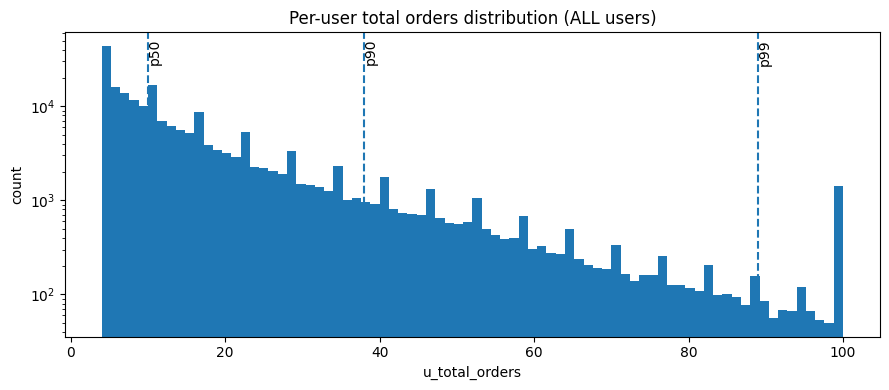


User coverage by minimum order threshold:
  users with >= 2 orders: 206209 (100.00%)
  users with >= 3 orders: 206209 (100.00%)
  users with >= 5 orders: 182223 (88.37%)
  users with >= 10 orders: 110728 (53.70%)
  users with >= 20 orders: 53931 (26.15%)
  users with >= 30 orders: 30677 (14.88%)

Filter: disabled for now; keep ALL users
  orders (all users): (3421083, 7)
  purchases op_all (all users): (33741710, 12)


In [8]:
u_total_orders = orders.groupby("user_id")["order_number"].max()
qs = plot_hist_with_quantiles(
    u_total_orders,
    title="Per-user total orders distribution (ALL users)",
    xlabel="u_total_orders",
    bins=80,
    logy=True,
)

# Threshold diagnostics: how much user coverage remains under different minimum-order cutoffs
print("\nUser coverage by minimum order threshold:")
for th in [2, 3, 5, 10, 20, 30]:
    kept = int((u_total_orders >= th).sum())
    print(f"  users with >= {th} orders: {kept} ({kept/u_total_orders.shape[0]:.2%})")

# Current choice: do not apply a minimum-order filter yet; keep all users for EDA
print("\nFilter: disabled for now; keep ALL users")
orders_f = orders.copy()
op_f = op_all.copy()
print("  orders (all users):", orders_f.shape)
print("  purchases op_all (all users):", op_f.shape)

# 7. Define a new target order and split purchases into target vs history

In [9]:
# For each user, find the maximum order_number among orders that appear in op_f.
user_last_avail = (
    op_f.groupby("user_id")["order_number"].max().rename("target_order_number").reset_index()
)

# Map that order_number back to a concrete target order_id (if ties exist, keep the max order_id)
target_orders = orders_f.merge(user_last_avail, on="user_id", how="inner")
target_orders = target_orders[target_orders["order_number"] == target_orders["target_order_number"]].copy()
target_orders = target_orders.sort_values(["user_id", "order_id"]).groupby("user_id").tail(1)

target_order_id_by_user = target_orders.set_index("user_id")["order_id"].to_dict()

print("\nNew target orders (last available with details) AFTER filtering:")
print("  users with a target order:", len(target_order_id_by_user))
print("  target orders eval_set breakdown:")
print(target_orders["eval_set"].value_counts(dropna=False))

# Split the unified purchase table into target-order rows vs history rows
user_target_series = pd.Series(target_order_id_by_user)
op_f = op_f.copy()
op_f["target_order_id"] = op_f["user_id"].map(user_target_series)
op_f["is_target_order"] = (op_f["order_id"] == op_f["target_order_id"])

target_op = op_f[op_f["is_target_order"]].copy()
history_op = op_f[~op_f["is_target_order"]].copy()

print("  target_op rows:", target_op.shape)
print("  history_op rows:", history_op.shape)

# Users eligible for supervised learning under this split (must have at least one history order)
user_hist_orders = history_op.groupby("user_id")["order_id"].nunique()
eligible_users = user_hist_orders[user_hist_orders >= 1].index
print("  users with >=1 history order:", int(eligible_users.shape[0]))



New target orders (last available with details) AFTER filtering:
  users with a target order: 206209
  target orders eval_set breakdown:
eval_set
train    131186
prior     75023
Name: count, dtype: int64
  target_op rows: (2153402, 14)
  history_op rows: (31588308, 14)
  users with >=1 history order: 206209


# 8. Outlier inspection (no removal at this stage)

In [10]:
# We inspect extreme values in several key behavioral variables.
# At this stage, we do not remove any observations because most extremes reflect natural long-tail behavior rather than obvious data errors.

def print_outlier_summary(series: pd.Series, name: str):
    s = pd.Series(series).dropna().astype(float)
    q = s.quantile([0.50, 0.90, 0.95, 0.99, 0.999]).to_dict()
    print(f"\nOutlier inspection: {name}")
    print("  count:", int(s.shape[0]))
    print("  min/max:", float(s.min()), float(s.max()))
    print("  quantiles:", {k: float(v) for k, v in q.items()})

# 1) user total orders
print_outlier_summary(u_total_orders, "u_total_orders")

# 2) target basket size
bs_target_for_outlier = target_op.groupby("order_id")["product_id"].size()
print_outlier_summary(bs_target_for_outlier, "target basket size")

# 3) per-user unique products in history (candidate size)
h_u_unique_for_outlier = history_op.groupby("user_id")["product_id"].nunique()
print_outlier_summary(h_u_unique_for_outlier, "history unique products per user")

# 4) user-product purchase count
up_buy_cnt_for_outlier = history_op.groupby(["user_id", "product_id"])["order_id"].size()
print_outlier_summary(up_buy_cnt_for_outlier, "up_buy_cnt")

# 5) days_since_prior_order (note: this field is top-coded at 30 in the Instacart dataset)
days_since_series = orders_f["days_since_prior_order"]
print_outlier_summary(days_since_series, "days_since_prior_order")

print("\nOutlier treatment decision:")
print("  No outliers are removed at this stage.")
print("  Current interpretation: most extreme values reflect genuine long-tail user/product behavior, not obvious data errors.")
print("  We keep them for now and use quantiles / log-scale plots to describe them robustly.")



Outlier inspection: u_total_orders
  count: 206209
  min/max: 4.0 100.0
  quantiles: {0.5: 10.0, 0.9: 38.0, 0.95: 52.0, 0.99: 89.0, 0.999: 100.0}

Outlier inspection: target basket size
  count: 206209
  min/max: 1.0 80.0
  quantiles: {0.5: 9.0, 0.9: 21.0, 0.95: 26.0, 0.99: 36.0, 0.999: 51.0}

Outlier inspection: history unique products per user
  count: 206209
  min/max: 1.0 725.0
  quantiles: {0.5: 46.0, 0.9: 137.0, 0.95: 177.0, 0.99: 264.0, 0.999: 386.0}

Outlier inspection: up_buy_cnt
  count: 12945171
  min/max: 1.0 99.0
  quantiles: {0.5: 1.0, 0.9: 5.0, 0.95: 8.0, 0.99: 18.0, 0.999: 39.0}

Outlier inspection: days_since_prior_order
  count: 3421083
  min/max: 0.0 30.0
  quantiles: {0.5: 7.0, 0.9: 30.0, 0.95: 30.0, 0.99: 30.0, 0.999: 30.0}

Outlier treatment decision:
  No outliers are removed at this stage.
  Current interpretation: most extreme values reflect genuine long-tail user/product behavior, not obvious data errors.
  We keep them for now and use quantiles / log-scale p

# 9. EDA based on the target/history split


Figure 2: Target order basket size summary
  mean=10.44, median=9.00, p90=21.00


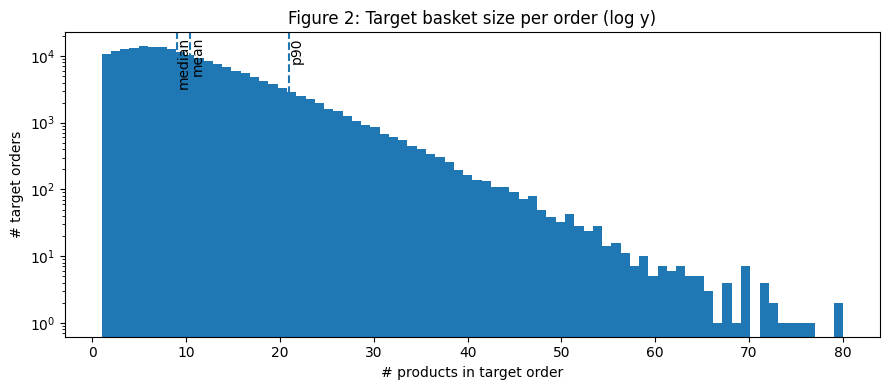

In [11]:
# 9.1 Figure 2: Target-order basket size distribution (supports Top-K choice)
# Basket size for each target order
bs_target = target_op.groupby("order_id")["product_id"].size().astype(float)
mean_bs = float(bs_target.mean())
median_bs = float(bs_target.median())
p90_bs = float(bs_target.quantile(0.90))

print("\nFigure 2: Target order basket size summary")
print(f"  mean={mean_bs:.2f}, median={median_bs:.2f}, p90={p90_bs:.2f}")

plt.figure(figsize=(9, 4))
plt.hist(bs_target.values, bins=80)
plt.yscale("log")
plt.axvline(mean_bs, linestyle="--")
plt.axvline(median_bs, linestyle="--")
plt.axvline(p90_bs, linestyle="--")

# Add simple reference labels
ymax = plt.ylim()[1]
plt.text(mean_bs, ymax * 0.85, "mean", rotation=90, va="top")
plt.text(median_bs, ymax * 0.85, "median", rotation=90, va="top")
plt.text(p90_bs, ymax * 0.85, "p90", rotation=90, va="top")

plt.title("Figure 2: Target basket size per order (log y)")
plt.xlabel("# products in target order")
plt.ylabel("# target orders")
plt.tight_layout()
plt.show()



Figure 3: Per-user unique products in HISTORY (candidate size)
  count: 206209
  quantiles: {0.5: 46.0, 0.9: 137.0, 0.99: 264.0}


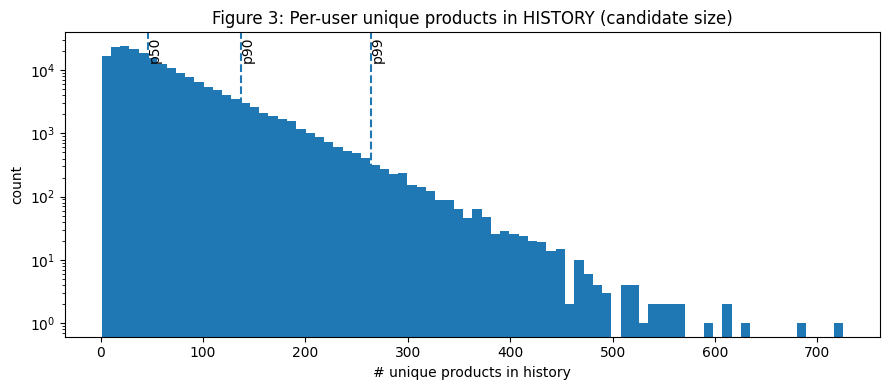


Figure 4: up_buy_cnt tail
  #(user,product) pairs with up_buy_cnt > 20: 98635


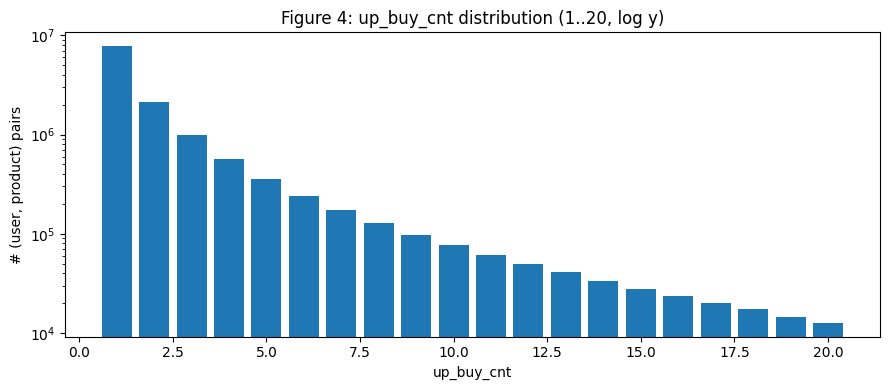

In [12]:
# 9.2 Figure 3: Candidate size per user in history (unique products)
h_u_unique = history_op.groupby("user_id")["product_id"].nunique()
plot_hist_with_quantiles(
    h_u_unique,
    title="Figure 3: Per-user unique products in HISTORY (candidate size)",
    xlabel="# unique products in history",
    bins=80,
    logy=True,
)

# 9.3 Figure 4: User-product purchase frequency distribution (up_buy_cnt)
up_buy_cnt = history_op.groupby(["user_id", "product_id"])["order_id"].size()
vc = up_buy_cnt.value_counts()
xs = list(range(1, 21))
ys = [int(vc.get(i, 0)) for i in xs]
ys_tail = int(vc[vc.index > 20].sum()) if (vc.index > 20).any() else 0

print("\nFigure 4: up_buy_cnt tail")
print("  #(user,product) pairs with up_buy_cnt > 20:", ys_tail)

plt.figure(figsize=(9, 4))
plt.bar(xs, ys)
plt.yscale("log")
plt.title("Figure 4: up_buy_cnt distribution (1..20, log y)")
plt.xlabel("up_buy_cnt")
plt.ylabel("# (user, product) pairs")
plt.tight_layout()
plt.show()



Figure 5: orders_since_last bins vs purchase probability
  bin  purchase_prob  n_pairs
    0            NaN        0
    1       0.279966  2119001
    2       0.162442  1510570
    3       0.111735  1203557
    4       0.083656   944551
    5       0.067383   767970
 6-10       0.044972  2416885
11-20       0.023702  2066741
  >20       0.010519  1915896


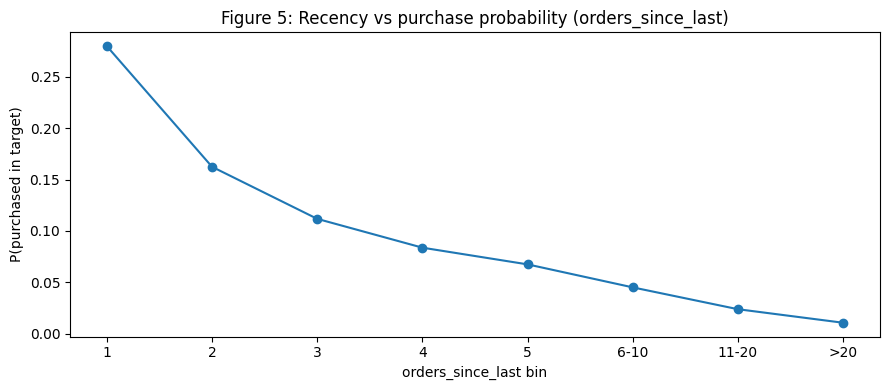

In [13]:
# 9.4 Figure 5: Recency vs purchase probability
# Build the binary label: whether a (user, product) pair appears in the target order
label_df = target_op[["user_id", "product_id"]].drop_duplicates().copy()
label_df["label"] = 1

# For each (user, product) pair in history, compute the last observed order_number
up_last = (
    history_op.groupby(["user_id", "product_id"])["order_number"].max().rename("up_last_order").reset_index()
)

# Target order_number for each user
user_target_on = target_orders[["user_id", "target_order_number"]].copy()

rec = up_last.merge(user_target_on, on="user_id", how="left")
rec["orders_since_last"] = (rec["target_order_number"] - rec["up_last_order"]).astype(float)

# Attach the binary label
rec = rec.merge(label_df, on=["user_id", "product_id"], how="left")
rec["label"] = rec["label"].fillna(0).astype(int)

# Bucket orders_since_last into interpretable bins
bins = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 10.5, 20.5, 1e9]
labels = ["0", "1", "2", "3", "4", "5", "6-10", "11-20", ">20"]
rec["bin"] = pd.cut(rec["orders_since_last"], bins=bins, labels=labels)

agg = rec.groupby("bin").agg(
    purchase_prob=("label", "mean"),
    n_pairs=("label", "size"),
).reset_index()

print("\nFigure 5: orders_since_last bins vs purchase probability")
print(agg.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.plot(agg["bin"].astype(str), agg["purchase_prob"], marker="o")
plt.title("Figure 5: Recency vs purchase probability (orders_since_last)")
plt.xlabel("orders_since_last bin")
plt.ylabel("P(purchased in target)")
plt.tight_layout()
plt.show()



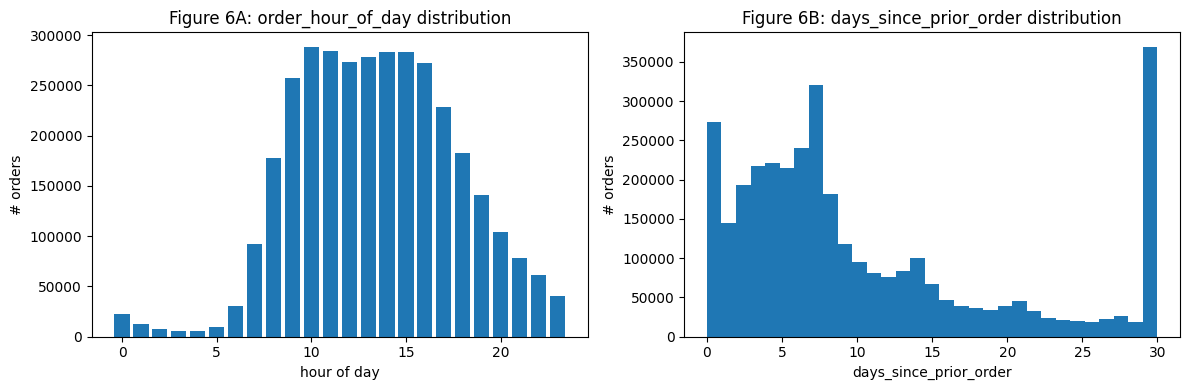


Figure 6: Temporal behavior summary
  order_hour_of_day top 5 hours:
order_hour_of_day
10    288418
11    284728
15    283639
14    283042
13    277999
  days_since_prior_order quantiles: {0.5: 7.0, 0.9: 30.0, 0.99: 30.0}


In [14]:
# 9.5 Figure 6: Temporal ordering behavior
# Use orders_f to show when users place orders and how long they wait between orders.
orders_time = orders_f.copy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
hour_counts = orders_time["order_hour_of_day"].value_counts().sort_index()
plt.bar(hour_counts.index.astype(int), hour_counts.values)
plt.title("Figure 6A: order_hour_of_day distribution")
plt.xlabel("hour of day")
plt.ylabel("# orders")

plt.subplot(1, 2, 2)
plt.hist(orders_time["days_since_prior_order"].values, bins=31)
plt.title("Figure 6B: days_since_prior_order distribution")
plt.xlabel("days_since_prior_order")
plt.ylabel("# orders")

plt.tight_layout()
plt.show()

print("\nFigure 6: Temporal behavior summary")
print("  order_hour_of_day top 5 hours:")
print(hour_counts.sort_values(ascending=False).head(5).to_string())
print("  days_since_prior_order quantiles:", orders_time["days_since_prior_order"].quantile([0.5, 0.9, 0.99]).to_dict())



Figure 7: Product-level summary
  p_total_purchases quantiles: {0.5: 61.0, 0.9: 1027.0, 0.99: 10014.800000000105}
  p_reorder_ratio quantiles: {0.5: 0.38095238095238093, 0.9: 0.6363636363636364, 0.99: 0.7758388681648624}


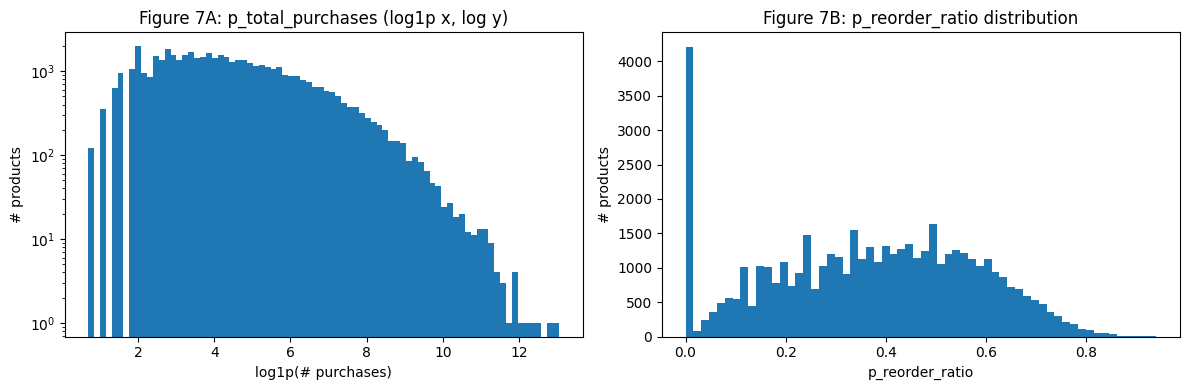

In [15]:
# 9.6 Figure 7: Product-level popularity and reorder behavior
# Use history_op so the EDA matches the future feature-building data source.
p_total_purchases = history_op.groupby("product_id")["order_id"].size().astype(float)
p_reorder_ratio = history_op.groupby("product_id")["reordered"].mean().astype(float)

print("\nFigure 7: Product-level summary")
print("  p_total_purchases quantiles:", p_total_purchases.quantile([0.5, 0.9, 0.99]).to_dict())
print("  p_reorder_ratio quantiles:", p_reorder_ratio.quantile([0.5, 0.9, 0.99]).to_dict())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(np.log1p(p_total_purchases.values), bins=80)
plt.yscale("log")
plt.title("Figure 7A: p_total_purchases (log1p x, log y)")
plt.xlabel("log1p(# purchases)")
plt.ylabel("# products")

plt.subplot(1, 2, 2)
plt.hist(p_reorder_ratio.values, bins=60)
plt.title("Figure 7B: p_reorder_ratio distribution")
plt.xlabel("p_reorder_ratio")
plt.ylabel("# products")

plt.tight_layout()
plt.show()


# 10. Department-level analysis


Department summary table
 department_id      department  purchase_count  unique_users  reorder_ratio
             4         produce         9251175        192360       0.649857
            16      dairy eggs         5291410        189418       0.670066
            19          snacks         2819833        172124       0.574233
             7       beverages         2625862        170792       0.653532
             1          frozen         2179561        161061       0.541749
            13          pantry         1829541        170410       0.346843
             3          bakery         1149448        138452       0.628229
            15    canned goods         1040700        131466       0.457324
            20            deli         1026198        131633       0.607681
             9 dry goods pasta          844412        122655       0.460738
            17       household          718699        109507       0.402220
            14       breakfast          692732        111981  

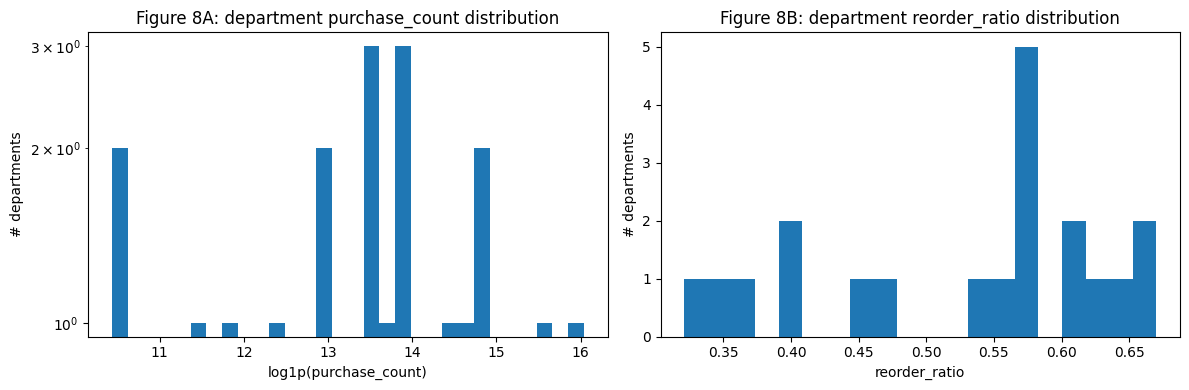

In [16]:
# history_op already inherits aisle/department metadata from op_all
hist_meta = history_op.copy()

# Aggregate summary at the department level

dep_summary = hist_meta.groupby(["department_id", "department"]).agg(
    purchase_count=("order_id", "size"),
    unique_users=("user_id", "nunique"),
    reorder_ratio=("reordered", "mean"),
).reset_index()

dep_summary = dep_summary.sort_values("purchase_count", ascending=False)

print("\nDepartment summary table")
print(dep_summary.to_string(index=False))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(np.log1p(dep_summary["purchase_count"].values.astype(float)), bins=30)
plt.yscale("log")
plt.title("Figure 8A: department purchase_count distribution")
plt.xlabel("log1p(purchase_count)")
plt.ylabel("# departments")

plt.subplot(1, 2, 2)
plt.hist(dep_summary["reorder_ratio"].values.astype(float), bins=20)
plt.title("Figure 8B: department reorder_ratio distribution")
plt.xlabel("reorder_ratio")
plt.ylabel("# departments")

plt.tight_layout()
plt.show()

# 11. Aisle-level analysis


Top 15 aisles by purchase_count
 aisle_id                         aisle  purchase_count  unique_users  reorder_ratio
       24                  fresh fruits         3557913        175505       0.717928
       83              fresh vegetables         3334147        157589       0.594550
      123    packaged vegetables fruits         1721841        157200       0.638393
      120                        yogurt         1420886        122489       0.686725
       21               packaged cheese          956306        130789       0.585292
       84                          milk          872160        107494       0.781404
      115 water seltzer sparkling water          821332         97986       0.729461
      107                chips pretzels          704564        109816       0.588808
       91               soy lactosefree          623615         94671       0.692533
      112                         bread          571548        101697       0.670199
       31                  refri

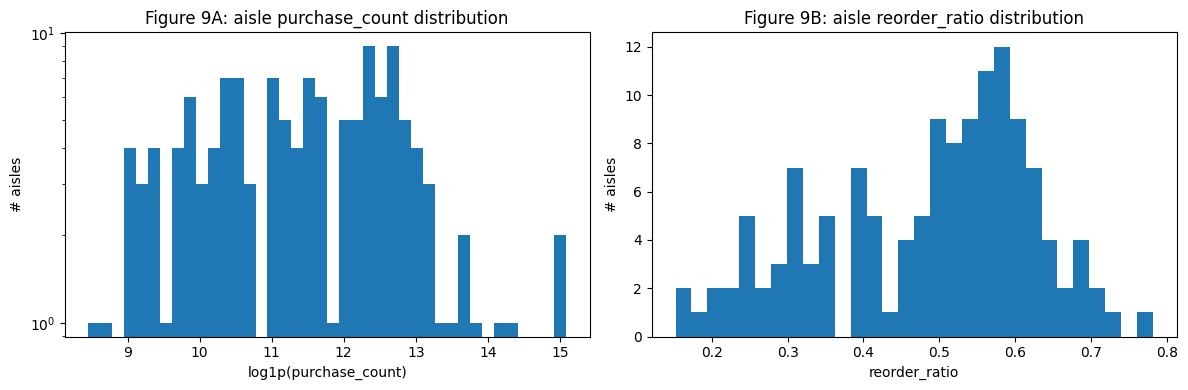

In [17]:
aisle_summary = hist_meta.groupby(["aisle_id", "aisle"]).agg(
    purchase_count=("order_id", "size"),
    unique_users=("user_id", "nunique"),
    reorder_ratio=("reordered", "mean"),
).reset_index()

aisle_summary = aisle_summary.sort_values("purchase_count", ascending=False)

print("\nTop 15 aisles by purchase_count")
print(aisle_summary.head(15).to_string(index=False))

MIN_CNT = 1000
print(f"\nTop 15 aisles by reorder_ratio (purchase_count >= {MIN_CNT})")
print(
    aisle_summary[aisle_summary["purchase_count"] >= MIN_CNT]
    .sort_values("reorder_ratio", ascending=False)
    .head(15)
    .to_string(index=False)
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(np.log1p(aisle_summary["purchase_count"].values.astype(float)), bins=40)
plt.yscale("log")
plt.title("Figure 9A: aisle purchase_count distribution")
plt.xlabel("log1p(purchase_count)")
plt.ylabel("# aisles")

plt.subplot(1, 2, 2)
plt.hist(aisle_summary["reorder_ratio"].values.astype(float), bins=30)
plt.title("Figure 9B: aisle reorder_ratio distribution")
plt.xlabel("reorder_ratio")
plt.ylabel("# aisles")

plt.tight_layout()
plt.show()

## =============================
# 12. End of EDA pipeline
## =============================

## =============================
# User and Product Analysis
## =============================

In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 6. User clustering based on history behavior

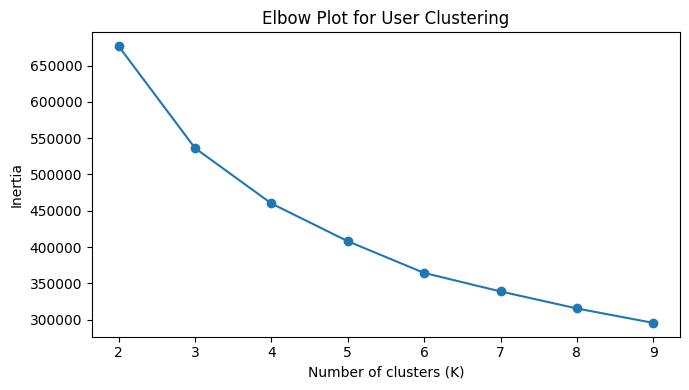

In [19]:
history_users = history_op[history_op["user_id"].isin(eligible_users)].copy()

 # `op_all` built in the EDA section does not carry temporal order metadata,
 # so we re-attach the needed order-level fields from `orders` here.
hist_orders = (
    history_users[["user_id", "order_id", "order_number"]]
    .drop_duplicates(subset=["order_id"])
    .merge(
        orders[["order_id", "order_dow", "order_hour_of_day", "days_since_prior_order"]],
        on="order_id",
        how="left",
    )
    .copy()
)

hist_order_size = (
    history_users.groupby(["user_id", "order_id"])["product_id"]
    .size()
    .rename("basket_size")
    .reset_index()
)

# User-level features for interpretable clustering
u_hist_orders = hist_orders.groupby("user_id")["order_id"].nunique().rename("u_hist_orders")
u_mean_days = hist_orders.groupby("user_id")["days_since_prior_order"].mean().rename("u_mean_days_between_orders")
u_mean_basket = hist_order_size.groupby("user_id")["basket_size"].mean().rename("u_mean_basket_size")
u_reorder_rate = history_users.groupby("user_id")["reordered"].mean().rename("u_reorder_rate")
u_unique_products = history_users.groupby("user_id")["product_id"].nunique().rename("u_unique_products")

user_cluster_features = pd.concat([
    u_hist_orders,
    u_mean_days,
    u_mean_basket,
    u_reorder_rate,
    u_unique_products,
], axis=1).reset_index()

user_cluster_features_raw = user_cluster_features.copy()

cluster_feature_cols = [
    "u_hist_orders",
    "u_mean_days_between_orders",
    "u_mean_basket_size",
    "u_reorder_rate",
    "u_unique_products",
]

# Light transformation for long-tail variables before scaling
for col in ["u_hist_orders", "u_mean_basket_size", "u_unique_products"]:
    user_cluster_features[col] = np.log1p(user_cluster_features[col])

X_user = user_cluster_features[cluster_feature_cols].fillna(0).copy()
scaler = StandardScaler()
X_user_scaled = scaler.fit_transform(X_user)

# Elbow method
k_values = list(range(2, 10))
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_user_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Plot for User Clustering")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

In [20]:
# 6.1 KMeans user clustering with 5 interpretable features (K=4)
kmeans_user = KMeans(n_clusters=4, random_state=420, n_init=20)
user_cluster_features["user_cluster"] = kmeans_user.fit_predict(X_user_scaled)

cluster_sizes = (
    user_cluster_features["user_cluster"]
    .value_counts()
    .sort_index()
    .rename("n_users")
    .reset_index()
    .rename(columns={"index": "user_cluster"})
)

user_cluster_features_raw["user_cluster"] = user_cluster_features["user_cluster"].values

cluster_profile_raw_cols = [
    "u_hist_orders",
    "u_mean_days_between_orders",
    "u_mean_basket_size",
    "u_reorder_rate",
    "u_unique_products",
]

cluster_profile_raw = (
    user_cluster_features_raw.groupby("user_cluster")[cluster_profile_raw_cols]
    .mean()
    .reset_index()
)

print("\nUser cluster sizes (5-feature KMeans, K=4):")
print("K candidates checked:", k_values)
print("Inertias:", [round(x, 2) for x in inertias])
print(cluster_sizes.to_string(index=False))

print("\nUser cluster profile on RAW scale (5 clustering features):")
print(cluster_profile_raw.to_string(index=False))

print(
    "\nCluster interpretation:\n"
    "Cluster 0：低复购、轻度探索\n"
    "Cluster 1：小篮子、少品类、固定补货\n"
    "Cluster 2：高活跃、高复购、核心重度\n"
    "Cluster 3：大篮子、高广度、周期性囤货"
)


User cluster sizes (5-feature KMeans, K=4):
K candidates checked: [2, 3, 4, 5, 6, 7, 8, 9]
Inertias: [676620.25, 536309.18, 460067.77, 408115.07, 364480.26, 339007.91, 315547.7, 295699.93]
 user_cluster  n_users
            0    64733
            1    61661
            2    42224
            3    37591

User cluster profile on RAW scale (5 clustering features):
 user_cluster  u_hist_orders  u_mean_days_between_orders  u_mean_basket_size  u_reorder_rate  u_unique_products
            0      32.779309                    8.761034           11.120919        0.627606         113.421887
            1       8.410405                   17.135110           12.681294        0.357215          60.751772
            2       4.693066                    8.947882            9.710516        0.223303          31.553406
            3       8.006943                   15.342642            3.524225        0.402890          13.958288

Cluster interpretation:
Cluster 0：低复购、轻度探索
Cluster 1：小篮子、少品类、固定补货
Cluster 

# 7. Basket-level association analysis for bundling opportunities

In [21]:
# Goal:
# Identify co-purchase patterns that can support bundling, cross-sell,
# and category-operation discussions.

basket_aisles = (
    op_all.groupby("order_id")["aisle"]
    .apply(lambda x: sorted(set(x.dropna().astype(str))))
    .reset_index(name="aisle_basket")
)

basket_aisles = basket_aisles[basket_aisles["aisle_basket"].str.len() >= 2].copy()
n_baskets = len(basket_aisles)

single_counts = {}
pair_counts = {}

for basket in basket_aisles["aisle_basket"]:
    for item in basket:
        single_counts[item] = single_counts.get(item, 0) + 1

    for i in range(len(basket)):
        for j in range(i + 1, len(basket)):
            pair = (basket[i], basket[j])
            pair_counts[pair] = pair_counts.get(pair, 0) + 1

rule_rows = []
for (a, b), pair_cnt in pair_counts.items():
    support = pair_cnt / n_baskets
    conf_a_to_b = pair_cnt / single_counts[a]
    conf_b_to_a = pair_cnt / single_counts[b]
    lift_a_to_b = conf_a_to_b / (single_counts[b] / n_baskets)
    lift_b_to_a = conf_b_to_a / (single_counts[a] / n_baskets)

    rule_rows.append({
        "antecedent": a,
        "consequent": b,
        "pair_count": pair_cnt,
        "support": support,
        "confidence": conf_a_to_b,
        "lift": lift_a_to_b,
    })
    rule_rows.append({
        "antecedent": b,
        "consequent": a,
        "pair_count": pair_cnt,
        "support": support,
        "confidence": conf_b_to_a,
        "lift": lift_b_to_a,
    })

rules_df = pd.DataFrame(rule_rows)

# Thresholds for actionable bundling relations
min_support = 0.01
min_confidence = 0.30
min_lift = 1.30

rules_filtered = rules_df[
    (rules_df["support"] >= min_support) &
    (rules_df["confidence"] >= min_confidence) &
    (rules_df["lift"] >= min_lift)
].copy()

rules_filtered = rules_filtered.sort_values(
    ["lift", "confidence", "pair_count"],
    ascending=[False, False, False]
).reset_index(drop=True)

# Treat A->B and B->A as one unordered pair
rules_filtered["pair_key"] = rules_filtered.apply(
    lambda row: tuple(sorted([row["antecedent"], row["consequent"]])),
    axis=1,
)

unique_rule_pairs_count = rules_filtered["pair_key"].nunique()

rules_unique_pairs = (
    rules_filtered.sort_values(
        ["lift", "confidence", "pair_count"],
        ascending=[False, False, False]
    )
    .drop_duplicates(subset=["pair_key"])
    .reset_index(drop=True)
)

rules_top = rules_unique_pairs.head(15).copy()

print("\nUnique deduplicated bundling pairs after filtering:", unique_rule_pairs_count)
print("\nTop aisle-level association rules for bundling opportunities:")
if len(rules_top) == 0:
    print("No aisle-level rules passed the current support/confidence/lift thresholds.")
else:
    print(rules_top.drop(columns=["pair_key"]).to_string(index=False))



Unique deduplicated bundling pairs after filtering: 137

Top aisle-level association rules for bundling opportunities:
            antecedent       consequent  pair_count  support  confidence     lift
           pasta sauce        dry pasta       65410 0.020860    0.314931 4.180565
preserved dips spreads   chips pretzels       45898 0.014637    0.430220 2.416904
  fresh dips tapenades   chips pretzels      117708 0.037538    0.359870 2.021689
               granola           yogurt       51217 0.016333    0.548808 1.967582
         cookies cakes   chips pretzels       68121 0.021724    0.347273 1.950920
         popcorn jerky   chips pretzels       51668 0.016477    0.343045 1.927168
fruit vegetable snacks   chips pretzels       52413 0.016715    0.342045 1.921555
            lunch meat            bread      113505 0.036197    0.326938 1.876924
tofu meat alternatives  soy lactosefree       37055 0.011817    0.337459 1.875500
           pasta sauce  packaged cheese       91691 0.029241

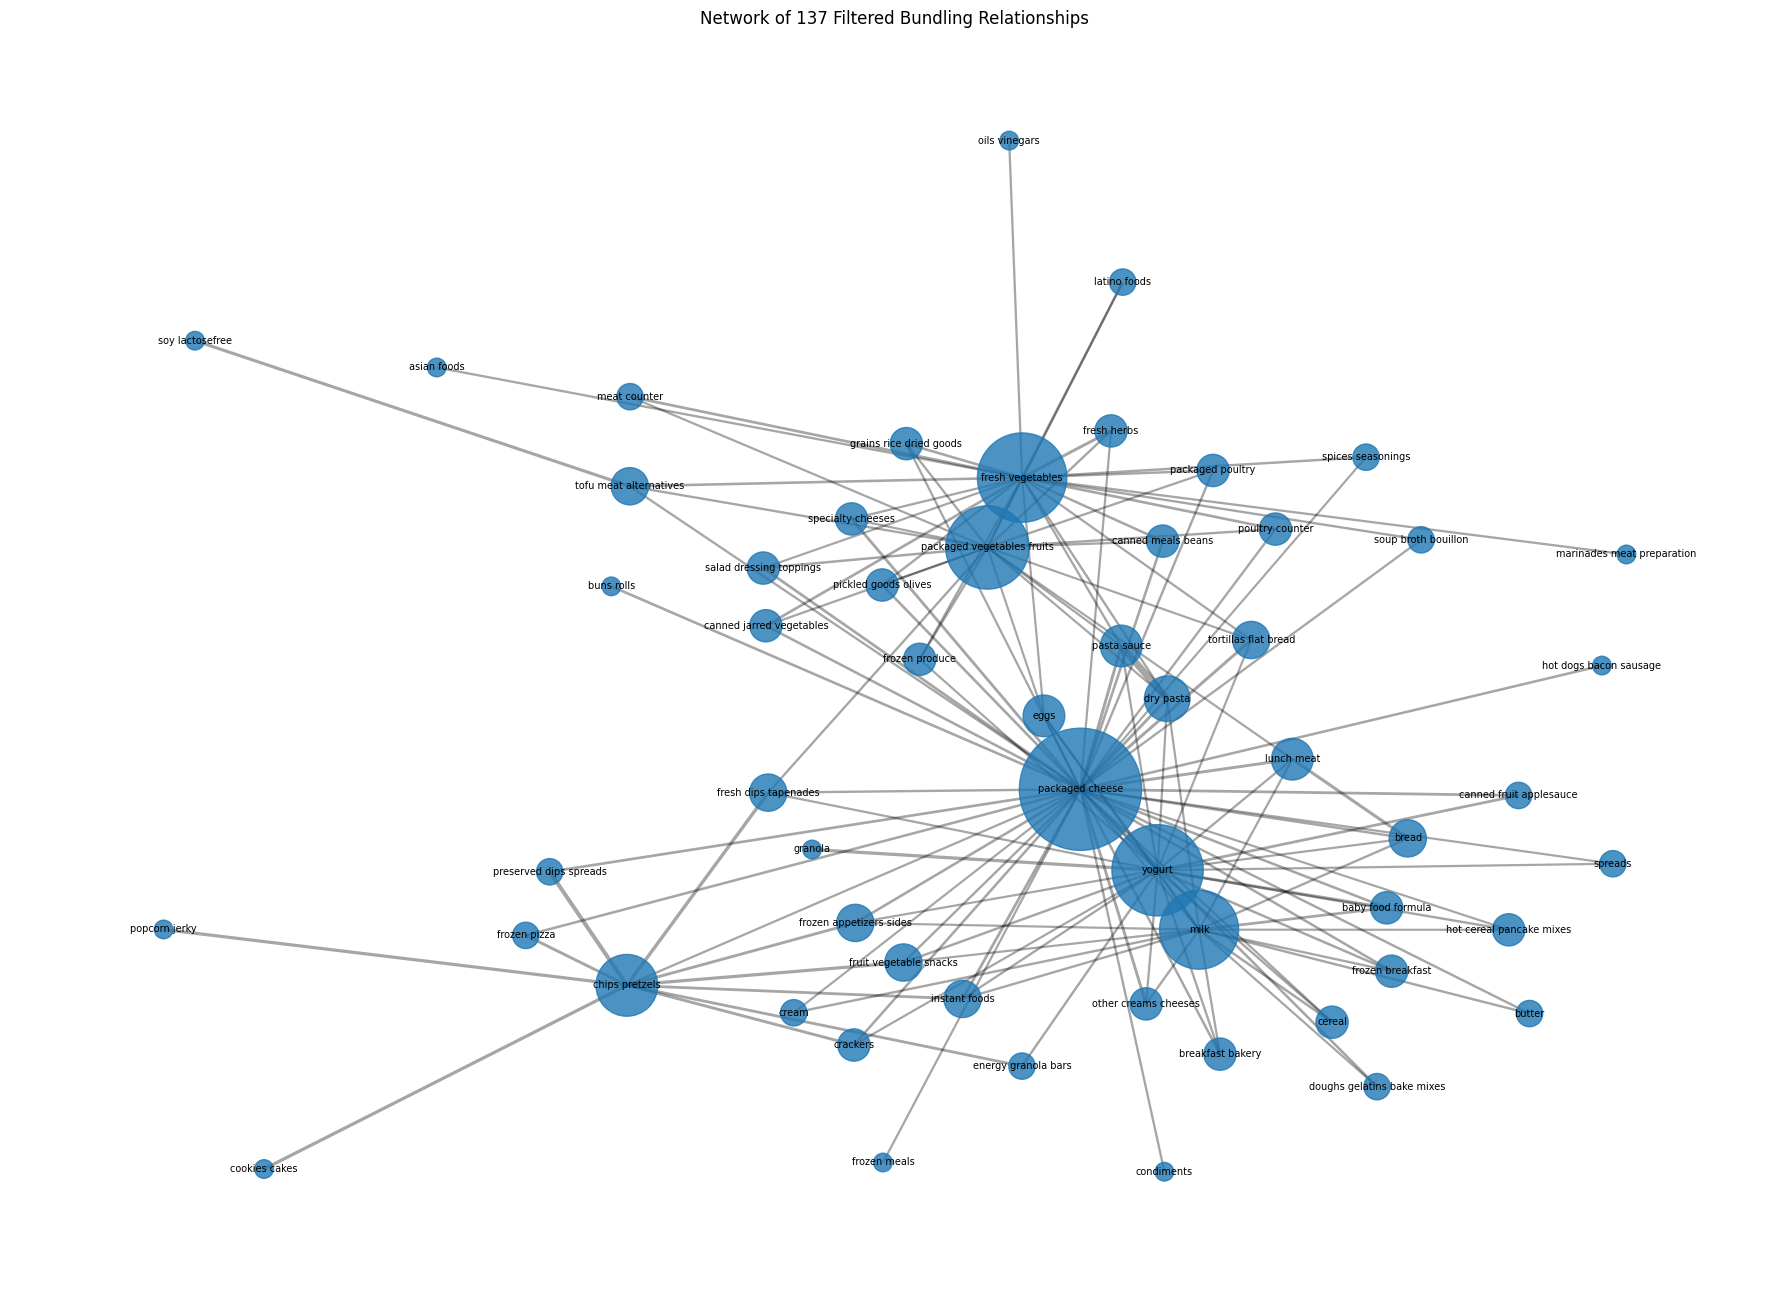

In [22]:
# 7.0A Visualize bundling network
if len(rules_unique_pairs) > 0:
    try:
        import networkx as nx

        rules_plot = rules_unique_pairs.copy()

        G = nx.Graph()
        for _, row in rules_plot.iterrows():
            G.add_edge(
                row["antecedent"],
                row["consequent"],
                weight=row["lift"],
                support=row["support"],
                pair_count=row["pair_count"],
            )

        node_degree = dict(G.degree())
        node_sizes = [node_degree[node] * 180 for node in G.nodes()]
        edge_widths = [G[u][v]["weight"] * 1.2 for u, v in G.edges()]

        plt.figure(figsize=(18, 13))
        pos = nx.spring_layout(G, seed=42, k=1.6, iterations=200)

        nx.draw_networkx_nodes(
            G,
            pos,
            node_size=node_sizes,
            alpha=0.8,
        )
        nx.draw_networkx_edges(
            G,
            pos,
            width=edge_widths,
            alpha=0.35,
        )
        nx.draw_networkx_labels(
            G,
            pos,
            labels={node: node for node in G.nodes()},
            font_size=7,
        )

        plt.title(f"Network of {len(rules_unique_pairs)} Filtered Bundling Relationships")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("networkx is not installed, so the bundling network graph was skipped.")


In [23]:
# 7.1 Cross-sell candidates from user segments
user_cluster_map = user_cluster_features_raw[["user_id", "user_cluster"]].copy()

cluster_aisle_pref = (
    history_users[["user_id", "aisle"]]
    .merge(user_cluster_map, on="user_id", how="left")
    .groupby(["user_cluster", "aisle"])
    .size()
    .rename("purchase_count")
    .reset_index()
)

cluster_totals = (
    cluster_aisle_pref.groupby("user_cluster")["purchase_count"]
    .sum()
    .rename("cluster_total_purchases")
    .reset_index()
)

cluster_aisle_pref = cluster_aisle_pref.merge(cluster_totals, on="user_cluster", how="left")
cluster_aisle_pref["cluster_purchase_share"] = (
    cluster_aisle_pref["purchase_count"] /
    cluster_aisle_pref["cluster_total_purchases"]
)

cluster_top_aisles = (
    cluster_aisle_pref.sort_values(
        ["user_cluster", "cluster_purchase_share", "purchase_count"],
        ascending=[True, False, False]
    )
    .groupby("user_cluster")
    .head(5)
    .reset_index(drop=True)
)

print("\nTop aisle preferences by user cluster:")
print(cluster_top_aisles.to_string(index=False))


Top aisle preferences by user cluster:
 user_cluster                         aisle  purchase_count  cluster_total_purchases  cluster_purchase_share
            0                  fresh fruits         2658872                 22498839                0.118178
            0              fresh vegetables         2398417                 22498839                0.106602
            0    packaged vegetables fruits         1252041                 22498839                0.055649
            0                        yogurt         1064361                 22498839                0.047307
            0               packaged cheese          680945                 22498839                0.030266
            1              fresh vegetables          689237                  6276668                0.109809
            1                  fresh fruits          609600                  6276668                0.097122
            1    packaged vegetables fruits          328701                  6276668    